# Assignment 2: Model training and predictions

### Loading libraries

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import randint
from mlxtend.plotting import scatterplotmatrix
import math
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA # Import PCA
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, RocCurveDisplay, roc_auc_score
from sklearn.metrics import precision_recall_curve, average_precision_score, PrecisionRecallDisplay

# Loading dataset:

## We will be using the bank_addition_full dataset since it has 4 additonal features and as per description on the website, it is very close to the dataset that was used for the analysis.

In [4]:
df = pd.read_csv('https://raw.githubusercontent.com/stormwhale/data-mines/refs/heads/main/bank-additional-full.csv', sep=';')


### Data Cleaning:

1) Handle the pdays with '-1' values:

    We Will replace '-1' as max(pdays)+1 and create a new column 'never contacted'
    
2) Exclude the duration column since it is a source of data leakage:

In [5]:
#Handle pdays '-1' values:
df['never_contacted'] = df['pdays'] == -1
df['pdays'] = df['pdays'].replace(-1, df['pdays'].max() + 1) #This will create a meaningful difference from the rest of the pdays numbers

#Exclude duration column:
df.drop('duration', axis=1, inplace=True)
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,never_contacted
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False


# Checking Missing values, data type, and duplicates:

In [6]:
#Checking missing values:
print('Missing values:\n',df.isnull().sum())
print('-'*80)
print(df.dtypes)
print('-'*80)
print('Duplicate rows:\n', df.duplicated().sum())

Missing values:
 age                0
job                0
marital            0
education          0
default            0
housing            0
loan               0
contact            0
month              0
day_of_week        0
campaign           0
pdays              0
previous           0
poutcome           0
emp.var.rate       0
cons.price.idx     0
cons.conf.idx      0
euribor3m          0
nr.employed        0
y                  0
never_contacted    0
dtype: int64
--------------------------------------------------------------------------------
age                  int64
job                 object
marital             object
education           object
default             object
housing             object
loan                object
contact             object
month               object
day_of_week         object
campaign             int64
pdays                int64
previous             int64
poutcome            object
emp.var.rate       float64
cons.price.idx     float64
cons.conf.idx   

### Since we have duplicates, we will investigate what they are and will eliminate duplicates if necessary.

In [7]:
df[df.duplicated(keep=False)].head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,never_contacted
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
10,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False
11,25,services,single,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no,False


In [8]:
#We will also eliminate the duplicates since they are exact identificals.
df.drop(df[df.duplicated()].index, inplace=True)

print('Number of duplicate values:', df.duplicated().sum())

Number of duplicate values: 0


Text(0.5, 1.0, 'Correlation Matrix for Numerical Variables')

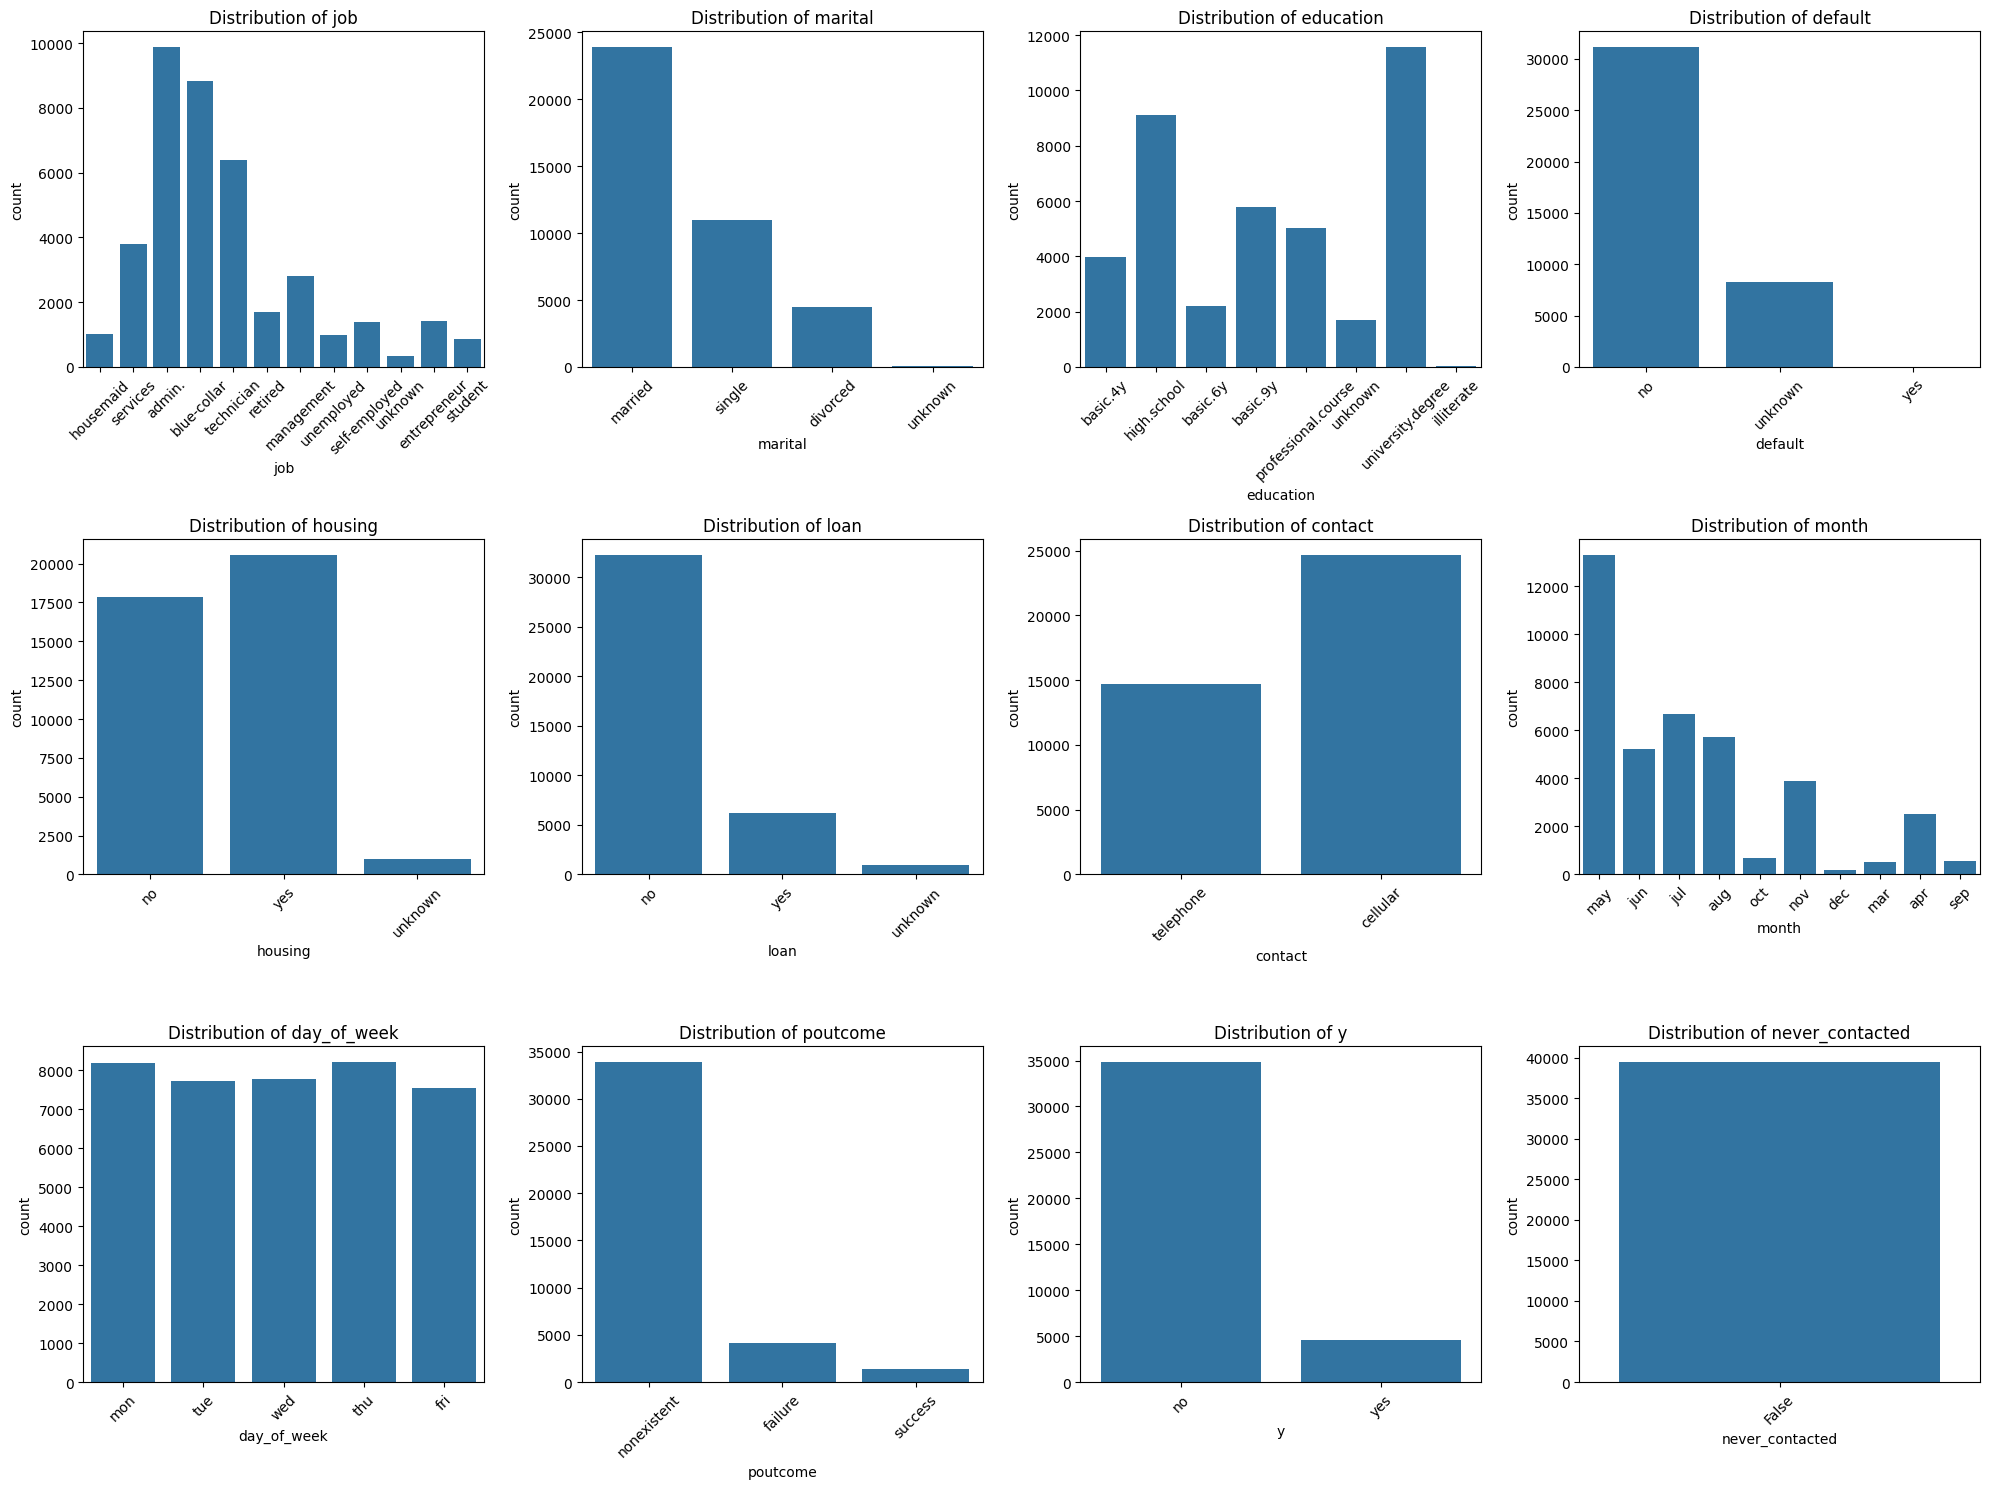

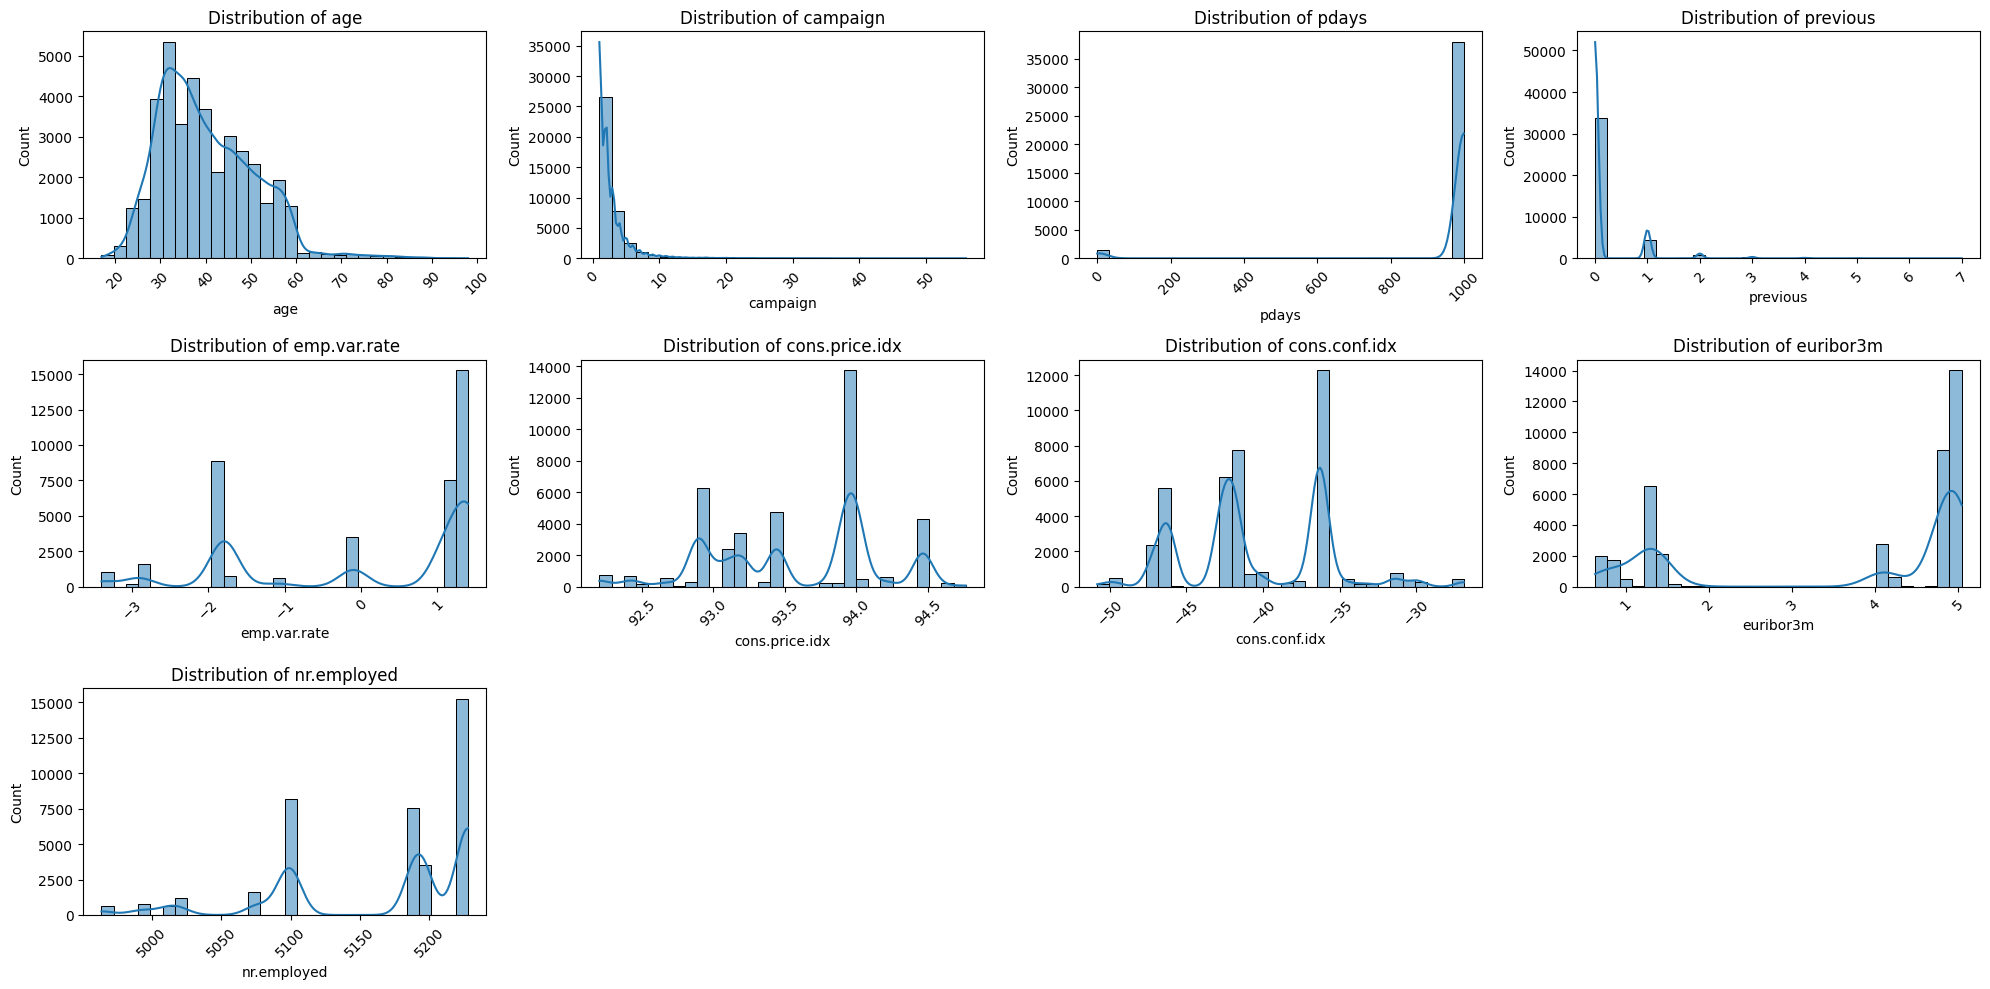

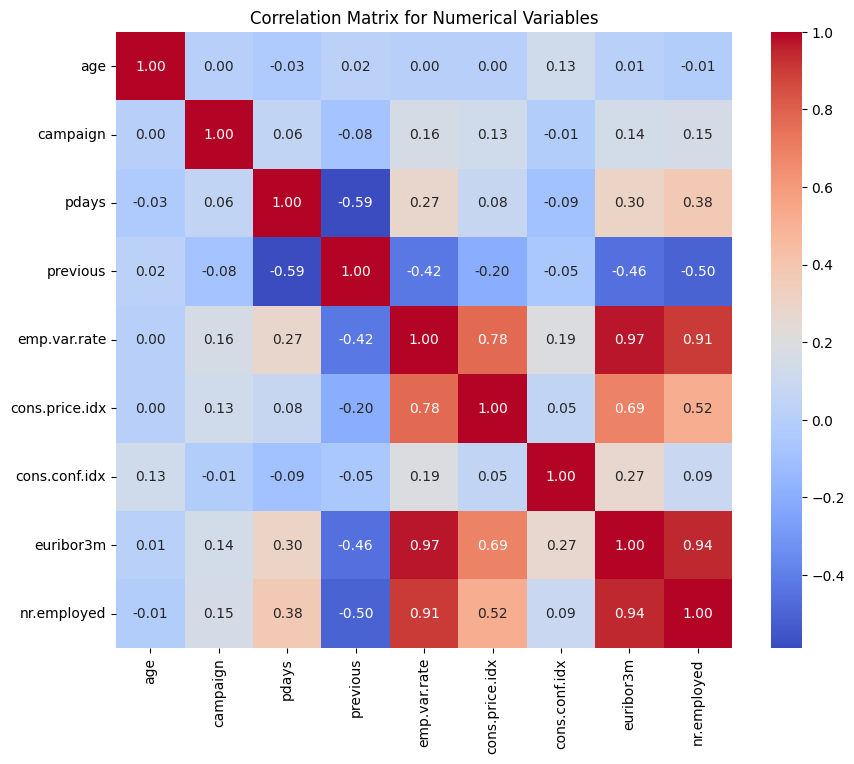

In [9]:
#Create visualizations for numerical and categorical variables:
df_cat = df.select_dtypes(include=['object', 'bool'])
df_num = df.select_dtypes(include=['int64', 'float64'])

#categorical variables:
plt.figure(figsize=(20, 15))
for i, column in enumerate(df_cat.columns, 1):
    plt.subplot(3, 4, i)
    sns.countplot(df_cat, x=column)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {column}')
plt.tight_layout()

#Numerical values:
plt.figure(figsize=(20, 10))
for i, column in enumerate(df_num.columns, 1):
    plt.subplot(3, 4, i)
    sns.histplot(df_num, x=column, kde=True, bins=30)
    plt.xticks(rotation=45)
    plt.title(f'Distribution of {column}')
plt.tight_layout()

#Correlation matrix for numerical variables:
plt.figure(figsize=(10, 8))
sns.heatmap(df_num.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix for Numerical Variables')


## There seems to have few features that showed multicolinearity. However, we are using tree-based models and multicolinearity would not affect the algorithms significantly.

# Checking for target variable imbalance.

In [10]:
no_per = df['y'].value_counts()['no']/df['y'].value_counts().sum() * 100
yes_per = 100 - no_per
print('Percentage of no:', round(no_per), '%')
print('Percentage of yes:', round(yes_per), '%')


Percentage of no: 88 %
Percentage of yes: 12 %


## There is a data imbalance in the target variable, where No is >> then Yes. We will have to address that when building the ML models.

# Split the target variable with features and train-split the data 80/20 split:

# Also use the 'straify' option since it maintains the same data distribution during the split. Very important in imbalanced data.

In [11]:
X = df.drop('y', axis = 1)
y = df['y'].apply(lambda x: 1 if x =='yes' else 0)

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y) #stratify to maintain the same proportion of classes in train and test sets especially when the distribution of the target variable is imbalanced

# Experiment parameters:

a) **Objective**: The model will be more effective in predicting negative values due to imbalanced target variable--more negative data available. We will attempt to re-balance the data as much as possible to create a more well-rounded predictive model with focus on the recall (sensitivity) for the positive outcome. This is because from a business standpoint we want to capture as many potential subscribers as possible, increasing the company's revenue.

b) **Parameters**: We will focus on techniques such as hyperparameter tuning, addig model weight, randomizing the grid search, and data resampling.

c) **Metric**: The F1 Macro score will be the evaluation metric due to how it measures the harmonic balance between precision and recall independently among the classes and averages them. 'Accuracry' here will be inapproperiate since the majority data class will mask the measurements on the minority data group. Individual recall and f1-score will also be examined.


Create a pipeline to do the following with pre-defined grid search with 5-fold CV (classes are balanced):

    1) OneHotEncode the categorical columns
    2) train a simple decision tree model (This will serve as a baseline model)
    3) train a randomforest model
    4) train an Adaboost model
    5) train a XGBoost model

metrics = f1_macro for independent evaluation of the model performance

# Experiemnt # 1:

##Conditions:

### 1) **imbalance** data is NOT addressed.
### 2) Pre-defined grid search
### 3) 5-fold cross-validation
### 4) Evaluation metric = f1_macro since it can evaluate the classes independently and then take the average for the final result. The final model is therefore balanced between the classes

In [15]:
#Define numerical and categorical data:
categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ]
)

#Simple decision tree pipeline:
imb_simple_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('simpleTree', DecisionTreeClassifier(random_state=42))
])

#rf pipeline:
imb_rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42))#Adding class_weight = balance to offset the target variable imbalance
])

#Adaboost pipeline:
imb_adaboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('adaboost', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42), random_state=42))
])

imb_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss'))
])

#Define grid search parameters for RandomForest and XGBoost:
simpleTree_grid ={
    'simpleTree__criterion': ['gini', 'entropy'],
    'simpleTree__max_depth': [5, 10, 20]
}
rf_param_grid = {
    'rf__n_estimators': [200, 250],
    'rf__max_depth': [5, 10, 20]
}
adaboost_param_grid = {
    'adaboost__n_estimators': [50, 100],
    'adaboost__learning_rate': [0.01, 0.1, 0.2]
}
xgb_param_grid = {
    'xgb__n_estimators': [200, 250],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

#Grid search with 5-fold CV and scoring = f1_macro:
imbal_GridSearchCV_simpleTree = GridSearchCV(imb_simple_tree_pipeline, param_grid=simpleTree_grid, cv=5, scoring = 'f1_macro', n_jobs=-1) #Scoring here is changed to f1_macro to capture a more balanced outcome due to data imbalance.
imbal_GridSearchCV_rf = GridSearchCV(imb_rf_pipeline, param_grid=rf_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
imbal_GridSearchCV_ada = GridSearchCV(imb_adaboost_pipeline, param_grid=adaboost_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
imbal_GridSearchCV_xgb = GridSearchCV(imb_xgb_pipeline, param_grid=xgb_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)

#Fitting the models:
imbal_GridSearchCV_simpleTree.fit(train_X, train_y)
imbal_GridSearchCV_rf.fit(train_X, train_y)
imbal_GridSearchCV_ada.fit(train_X, train_y)
imbal_GridSearchCV_xgb.fit(train_X, train_y)

#Get the best parameters and best scores:
print('Best parameters for imbalanced simple decision tree:', imbal_GridSearchCV_simpleTree.best_params_)
print('Best parameters for imbalanced RandmForest:', imbal_GridSearchCV_rf.best_params_)
print('Best parameters for imbalanced AdaBoost:', imbal_GridSearchCV_ada.best_params_)
print('Best parameters for imbalanced XGBoost:', imbal_GridSearchCV_xgb.best_params_)
print('-'*80)
print(f'Best imbalanced training / test score for simple decision tree: {imbal_GridSearchCV_simpleTree.best_score_:.2f} / {imbal_GridSearchCV_simpleTree.score(test_X, test_y):.2f}')
print(f'Best imbalanced training / test score for RandomForest: {imbal_GridSearchCV_rf.best_score_:.2f} / {imbal_GridSearchCV_rf.score(test_X, test_y):.2f}')
print(f'Best imbalanced training / test score for AdaBoost: {imbal_GridSearchCV_ada.best_score_:.2f} / {imbal_GridSearchCV_ada.score(test_X, test_y):.2f}')
print(f'Best imbalanced training / test score for XGBoost: {imbal_GridSearchCV_xgb.best_score_:.2f} / {imbal_GridSearchCV_xgb.score(test_X, test_y):.2f}')
print('-'*80)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [01:42:33] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for imbalanced simple decision tree: {'simpleTree__criterion': 'entropy', 'simpleTree__max_depth': 5}
Best parameters for imbalanced RandmForest: {'rf__max_depth': 20, 'rf__n_estimators': 200}
Best parameters for imbalanced AdaBoost: {'adaboost__learning_rate': 0.2, 'adaboost__n_estimators': 100}
Best parameters for imbalanced XGBoost: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 5, 'xgb__n_estimators': 250}
--------------------------------------------------------------------------------
Best imbalanced training / test score for simple decision tree: 0.66 / 0.67
Best imbalanced training / test score for RandomForest: 0.66 / 0.67
Best imbalanced training / test score for AdaBoost: 0.61 / 0.63
Best imbalanced training / test score for XGBoost: 0.66 / 0.69
--------------------------------------------------------------------------------


# Experiment 1 Classification report:

In [16]:
y_pred_imbal_simpleTree = imbal_GridSearchCV_simpleTree.predict(test_X)
y_pred_imbal_rf = imbal_GridSearchCV_rf.predict(test_X)
y_pred_imbal_ada = imbal_GridSearchCV_ada.predict(test_X)
y_pred_imbal_xgb = imbal_GridSearchCV_xgb.predict(test_X)

print('Classification Report for simple decision tree:')
print(classification_report(test_y, y_pred_imbal_simpleTree))
print('-'*80)
print('Classification Report for RandomForest:')
print(classification_report(test_y, y_pred_imbal_rf))
print('-'*80)
print('Classification Report for AdaBoost:')
print(classification_report(test_y, y_pred_imbal_ada))
print('-'*80)
print('Classification Report for XGBoost:')
print(classification_report(test_y, y_pred_imbal_xgb))

Classification Report for simple decision tree:
              precision    recall  f1-score   support

           0       0.91      0.98      0.95      6961
           1       0.68      0.28      0.40       920

    accuracy                           0.90      7881
   macro avg       0.80      0.63      0.67      7881
weighted avg       0.89      0.90      0.88      7881

--------------------------------------------------------------------------------
Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       0.91      0.97      0.94      6961
           1       0.60      0.29      0.39       920

    accuracy                           0.89      7881
   macro avg       0.76      0.63      0.67      7881
weighted avg       0.88      0.89      0.88      7881

--------------------------------------------------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

     

# Experiment 1 results:
## In this experiment, we can see the f1 macro scores are relatively low when the data are imbalanced evne though the hyperparameters were grid searched. The best classifier, XGB has very low recall score, 0.32, for the positive class while 0.97 recall for the negative class. This is the expected result from using imbalanced data to train the models.


# Experiemnt # 2:

##Conditions:

### 1) **Balanced** data.
### 2) Pre-defined grid search
### 3) 5-fold cross-validation
### 4) Evaluation metric = f1_macro

In [18]:
#Define transformer for categorical and numerical columns:

categorical_cols = X.select_dtypes(include=['object', 'bool']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('categorical', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('numerical', 'passthrough', numerical_cols)
    ]
)

#Simple decision tree pipeline:
simple_tree_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('simpleTree', DecisionTreeClassifier(random_state=42, class_weight='balanced')) #Adding class_weight = balance to offset the target variable imbalance
])

#rf pipeline:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('rf', RandomForestClassifier(random_state=42, class_weight='balanced'))#Adding class_weight = balance to offset the target variable imbalance
])

#Adaboost pipeline:
adaboost_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('adaboost', AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1, random_state=42, class_weight='balanced'), random_state=42))
])

#Define the scale_pos_weight for XGBoost:
neg, pos = np.bincount(train_y)
scale_pos_weight = neg/ pos

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight))
])

#Define grid search parameters for RandomForest and XGBoost:
simpleTree_grid ={
    'simpleTree__criterion': ['gini', 'entropy'],
    'simpleTree__max_depth': [5, 10, 20]
}
rf_param_grid = {
    'rf__n_estimators': [200, 250],
    'rf__max_depth': [5, 10, 20]
}
adaboost_param_grid = {
    'adaboost__n_estimators': [50, 100],
    'adaboost__learning_rate': [0.01, 0.1, 0.2]
}
xgb_param_grid = {
    'xgb__n_estimators': [200, 250],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

#Grid search with 5-fold CV and scoring = f1_macro:
GridSearchCV_simpleTree = GridSearchCV(simple_tree_pipeline, param_grid=simpleTree_grid, cv=5, scoring = 'f1_macro', n_jobs=-1) #Scoring here is changed to f1_macro to capture a more balanced outcome due to data imbalance.
GridSearchCV_rf = GridSearchCV(rf_pipeline, param_grid=rf_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
GridSearchCV_ada = GridSearchCV(adaboost_pipeline, param_grid=adaboost_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
GridSearchCV_xgb = GridSearchCV(xgb_pipeline, param_grid=xgb_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)

#Fitting the models:
GridSearchCV_simpleTree.fit(train_X, train_y)
GridSearchCV_rf.fit(train_X, train_y)
GridSearchCV_ada.fit(train_X, train_y)
GridSearchCV_xgb.fit(train_X, train_y)

#Get the best parameters and best scores:
print('Best parameters for simple decision tree:', GridSearchCV_simpleTree.best_params_)
print('Best parameters for RandmForest:', GridSearchCV_rf.best_params_)
print('Best parameters for AdaBoost:', GridSearchCV_ada.best_params_)
print('Best parameters for XGBoost:', GridSearchCV_xgb.best_params_)
print('-'*80)
print(f'Best training / test score for simple decision tree: {GridSearchCV_simpleTree.best_score_:.2f} / {GridSearchCV_simpleTree.score(test_X, test_y):.2f}')
print(f'Best training / test score for RandomForest: {GridSearchCV_rf.best_score_:.2f} / {GridSearchCV_rf.score(test_X, test_y):.2f}')
print(f'Best training / test score for AdaBoost: {GridSearchCV_ada.best_score_:.2f} / {GridSearchCV_ada.score(test_X, test_y):.2f}')
print(f'Best training / test score for XGBoost: {GridSearchCV_xgb.best_score_:.2f} / {GridSearchCV_xgb.score(test_X, test_y):.2f}')
print('-'*80)


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [01:47:53] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for simple decision tree: {'simpleTree__criterion': 'gini', 'simpleTree__max_depth': 5}
Best parameters for RandmForest: {'rf__max_depth': 10, 'rf__n_estimators': 250}
Best parameters for AdaBoost: {'adaboost__learning_rate': 0.01, 'adaboost__n_estimators': 50}
Best parameters for XGBoost: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 250}
--------------------------------------------------------------------------------
Best training / test score for simple decision tree: 0.68 / 0.67
Best training / test score for RandomForest: 0.70 / 0.70
Best training / test score for AdaBoost: 0.69 / 0.70
Best training / test score for XGBoost: 0.69 / 0.69
--------------------------------------------------------------------------------


# Experiment 2 Classification report:

In [19]:
y_pred_simpleTree = GridSearchCV_simpleTree.predict(test_X)
y_pred_rf = GridSearchCV_rf.predict(test_X)
y_pred_ada = GridSearchCV_ada.predict(test_X)
y_pred_xgb = GridSearchCV_xgb.predict(test_X)

print('Classification Report for simple decision tree:')
print(classification_report(test_y, y_pred_simpleTree))
print('-'*80)
print('Classification Report for RandomForest:')
print(classification_report(test_y, y_pred_rf))
print('-'*80)
print('Classification Report for AdaBoost:')
print(classification_report(test_y, y_pred_ada))
print('-'*80)
print('Classification Report for XGBoost:')
print(classification_report(test_y, y_pred_xgb))

Classification Report for simple decision tree:
              precision    recall  f1-score   support

           0       0.95      0.83      0.89      6961
           1       0.34      0.65      0.45       920

    accuracy                           0.81      7881
   macro avg       0.64      0.74      0.67      7881
weighted avg       0.88      0.81      0.83      7881

--------------------------------------------------------------------------------
Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       0.95      0.89      0.91      6961
           1       0.41      0.61      0.49       920

    accuracy                           0.85      7881
   macro avg       0.68      0.75      0.70      7881
weighted avg       0.88      0.85      0.87      7881

--------------------------------------------------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

     

# Experiment 2 results:
## After adding weight to the sample and therefore balancing the dataset, there is a substantial improvement in recall and f1-macro score for most of the models. RandomForest model had roughly 3% f1-macro score improvement from the imbalance data and almost doubled in the recall for the positive class. While the f1-macro score for XGB was roughly the same, the recall for the positive class also increased by 2 fold. This demonstrates the importance of balancing the data and how an imbalanced dataset can yield a model that is biased against the minority class.

# Experiment 3:
##Conditions:

### 1) **Balanced** data.
### 2) Random grid search
### 3) 5-fold cross-validation
### 4) Evaluation metric = f1_macro

In [20]:
#We will text random grid search:

simpleTree_rand_grid ={
    'simpleTree__criterion': ['gini', 'entropy'],
    'simpleTree__max_depth': randint(5, 100)
}
rf_param_rand_grid = {
    'rf__n_estimators': randint(50, 1000),
    'rf__max_depth': randint(5, 40)
}
adaboost_rand_param_grid = {
    'adaboost__n_estimators': randint(50, 1000),
    'adaboost__learning_rate': [0.01, 0.1, 0.2]
}
xgb_param_rand_grid = {
    'xgb__n_estimators': randint(50, 1000),
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': randint(1, 10)
}

#Grid search with 5-fold CV and scoring = f1_macro:
RandomizedSearchCV_simpleTree = RandomizedSearchCV(simple_tree_pipeline, param_distributions=simpleTree_rand_grid, cv=5, scoring = 'f1_macro', n_jobs=-1, n_iter=10, random_state=42)
RandomizedSearchCV_rf = RandomizedSearchCV(rf_pipeline, param_distributions=rf_param_rand_grid, cv=5, scoring = 'f1_macro', n_jobs=-1, n_iter=10, random_state=42)
RandomizedSearchCV_ada = RandomizedSearchCV(adaboost_pipeline, param_distributions=adaboost_rand_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1, n_iter=10, random_state=42)
RandomizedSearchCV_xgb = RandomizedSearchCV(xgb_pipeline, param_distributions=xgb_param_rand_grid, cv=5, scoring = 'f1_macro', n_jobs=-1, n_iter=10, random_state=42)

#Fitting the models:
RandomizedSearchCV_simpleTree.fit(train_X, train_y)
RandomizedSearchCV_rf.fit(train_X, train_y)
RandomizedSearchCV_ada.fit(train_X, train_y)
RandomizedSearchCV_xgb.fit(train_X, train_y)

#Get the best parameters and best scores:
print('Best parameters for RandomGrid search simple decision tree:', RandomizedSearchCV_simpleTree.best_params_)
print('Best parameters for RandomGrid search RandmForest:', RandomizedSearchCV_rf.best_params_)
print('Best parameters for RandomGrid search AdaBoost:', RandomizedSearchCV_ada.best_params_)
print('Best parameters for RandomGrid search XGBoost:', RandomizedSearchCV_xgb.best_params_)
print('-'*80)
print(f'Best RandomGrid search training / test score for simple decision tree: {RandomizedSearchCV_simpleTree.best_score_:.2f} / {RandomizedSearchCV_simpleTree.score(test_X, test_y):.2f}')
print(f'Best RandomGrid search training / test score for RandomForest: {RandomizedSearchCV_rf.best_score_:.2f} / {RandomizedSearchCV_rf.score(test_X, test_y):.2f}')
print(f'Best RandomGrid search training / test score for AdaBoost: {RandomizedSearchCV_ada.best_score_:.2f} / {RandomizedSearchCV_ada.score(test_X, test_y):.2f}')
print(f'Best RandomGrid search training / test score for XGBoost: {RandomizedSearchCV_xgb.best_score_:.2f} / {RandomizedSearchCV_xgb.score(test_X, test_y):.2f}')
print('-'*80)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:02:35] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for RandomGrid search simple decision tree: {'simpleTree__criterion': 'gini', 'simpleTree__max_depth': 6}
Best parameters for RandomGrid search RandmForest: {'rf__max_depth': 15, 'rf__n_estimators': 508}
Best parameters for RandomGrid search AdaBoost: {'adaboost__learning_rate': 0.2, 'adaboost__n_estimators': 485}
Best parameters for RandomGrid search XGBoost: {'xgb__learning_rate': 0.01, 'xgb__max_depth': 7, 'xgb__n_estimators': 171}
--------------------------------------------------------------------------------
Best RandomGrid search training / test score for simple decision tree: 0.67 / 0.67
Best RandomGrid search training / test score for RandomForest: 0.71 / 0.71
Best RandomGrid search training / test score for AdaBoost: 0.69 / 0.70
Best RandomGrid search training / test score for XGBoost: 0.69 / 0.68
--------------------------------------------------------------------------------


# Experiment 3 Classification report:

In [21]:
y_pred_RandomizedSearchCV_simpleTree = RandomizedSearchCV_simpleTree.predict(test_X)
y_pred_RandomizedSearchCV_rf = RandomizedSearchCV_rf.predict(test_X)
y_pred_RandomizedSearchCV_ada = RandomizedSearchCV_ada.predict(test_X)
y_pred_RandomizedSearchCV_xgb = RandomizedSearchCV_xgb.predict(test_X)

print('Classification Report for simple decision tree:')
print(classification_report(test_y, y_pred_RandomizedSearchCV_simpleTree))
print('-'*80)
print('Classification Report for RandomForest:')
print(classification_report(test_y, y_pred_RandomizedSearchCV_rf))
print('-'*80)
print('Classification Report for AdaBoost:')
print(classification_report(test_y, y_pred_RandomizedSearchCV_ada))
print('-'*80)
print('Classification Report for XGBoost:')
print(classification_report(test_y, y_pred_RandomizedSearchCV_xgb))

Classification Report for simple decision tree:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89      6961
           1       0.34      0.64      0.45       920

    accuracy                           0.81      7881
   macro avg       0.64      0.74      0.67      7881
weighted avg       0.88      0.81      0.84      7881

--------------------------------------------------------------------------------
Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6961
           1       0.46      0.53      0.49       920

    accuracy                           0.87      7881
   macro avg       0.70      0.72      0.71      7881
weighted avg       0.88      0.87      0.88      7881

--------------------------------------------------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

     

# Experiment 3 results:

## In this experiment, we attempted to expand the number of trees or iterations for each model. To compensate the computational time, we utilized a randomized grid search to find the most optimal hyperparameters. RandomForest showed the highest f1 macro score with the best parameter at n_estimator at 508, suggesting that the previous hyperparameters for the models might be too limited and need further investigation.

# Experiment 4:

##Conditions:

### 1) Sample imbalance is addressed with SMOTE method for **resampling**. Both minority and majority classes are equal in numbers.
### 2) Pre-defined grid search
### 3) 5-fold cross-validation
### 4) Evaluation metric = f1_macro

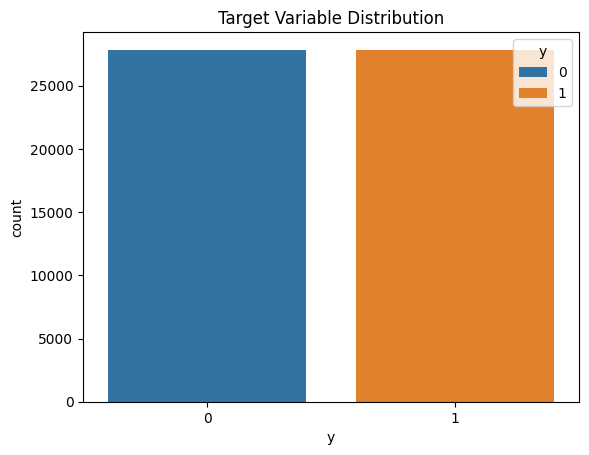

In [23]:
from imblearn.over_sampling import RandomOverSampler

#Resample the original dataset:
oversampler = RandomOverSampler(random_state=42, sampling_strategy='auto')
train_X_resampled, train_y_resampled = oversampler.fit_resample(train_X, train_y)

#Visualize the target variable distribution:
sns.barplot(x=train_y_resampled.value_counts().index,
            y=train_y_resampled.value_counts(),
            hue=train_y_resampled.value_counts().index)
plt.title('Target Variable Distribution')
plt.show()


In [24]:
simpleTree_grid ={
    'simpleTree__criterion': ['gini', 'entropy'],
    'simpleTree__max_depth': [5, 10, 20]
}
rf_param_grid = {
    'rf__n_estimators': [200, 250],
    'rf__max_depth': [5, 10, 20]
}
adaboost_param_grid = {
    'adaboost__n_estimators': [50, 100],
    'adaboost__learning_rate': [0.01, 0.1, 0.2]
}
xgb_param_grid = {
    'xgb__n_estimators': [200, 250],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7]
}

#Grid search with 5-fold CV and scoring = f1_macro:
res_GridSearchCV_simpleTree = GridSearchCV(simple_tree_pipeline, param_grid=simpleTree_grid, cv=5, scoring = 'f1_macro', n_jobs=-1) #Scoring here is changed to f1_macro to capture a more balanced outcome due to data imbalance.
res_GridSearchCV_rf = GridSearchCV(rf_pipeline, param_grid=rf_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
res_GridSearchCV_ada = GridSearchCV(adaboost_pipeline, param_grid=adaboost_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)
res_GridSearchCV_xgb = GridSearchCV(xgb_pipeline, param_grid=xgb_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)

#Fitting the models:
res_GridSearchCV_simpleTree.fit(train_X_resampled, train_y_resampled)
res_GridSearchCV_rf.fit(train_X_resampled, train_y_resampled)
res_GridSearchCV_ada.fit(train_X_resampled, train_y_resampled)
res_GridSearchCV_xgb.fit(train_X_resampled, train_y_resampled)

#Get the best parameters and best scores:
print('Best parameters for simple decision tree:', res_GridSearchCV_simpleTree.best_params_)
print('Best parameters for RandmForest:', res_GridSearchCV_rf.best_params_)
print('Best parameters for AdaBoost:', res_GridSearchCV_ada.best_params_)
print('Best parameters for XGBoost:', res_GridSearchCV_xgb.best_params_)
print('-'*80)
print(f'Best training / test score for simple decision tree: {res_GridSearchCV_simpleTree.best_score_:.2f} / {res_GridSearchCV_simpleTree.score(test_X, test_y):.2f}')
print(f'Best training / test score for RandomForest: {res_GridSearchCV_rf.best_score_:.2f} / {res_GridSearchCV_rf.score(test_X, test_y):.2f}')
print(f'Best training / test score for AdaBoost: {res_GridSearchCV_ada.best_score_:.2f} / {res_GridSearchCV_ada.score(test_X, test_y):.2f}')
print(f'Best training / test score for XGBoost: {res_GridSearchCV_xgb.best_score_:.2f} / {res_GridSearchCV_xgb.score(test_X, test_y):.2f}')
print('-'*80)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:30:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for simple decision tree: {'simpleTree__criterion': 'gini', 'simpleTree__max_depth': 20}
Best parameters for RandmForest: {'rf__max_depth': 20, 'rf__n_estimators': 250}
Best parameters for AdaBoost: {'adaboost__learning_rate': 0.2, 'adaboost__n_estimators': 100}
Best parameters for XGBoost: {'xgb__learning_rate': 0.2, 'xgb__max_depth': 7, 'xgb__n_estimators': 250}
--------------------------------------------------------------------------------
Best training / test score for simple decision tree: 0.87 / 0.60
Best training / test score for RandomForest: 0.94 / 0.70
Best training / test score for AdaBoost: 0.73 / 0.69
Best training / test score for XGBoost: 0.82 / 0.55
--------------------------------------------------------------------------------


# Experiment 4 Classification report:

In [25]:
y_pred_res_simpleTree = res_GridSearchCV_simpleTree.predict(test_X)
y_pred_res_rf = res_GridSearchCV_rf.predict(test_X)
y_pred_res_ada = res_GridSearchCV_ada.predict(test_X)
y_pred_res_xgb = res_GridSearchCV_xgb.predict(test_X)

print('Classification Report for simple decision tree:')
print(classification_report(test_y, y_pred_res_simpleTree))
print('-'*80)
print('Classification Report for RandomForest:')
print(classification_report(test_y, y_pred_res_rf))
print('-'*80)
print('Classification Report for AdaBoost:')
print(classification_report(test_y, y_pred_res_ada))
print('-'*80)
print('Classification Report for XGBoost:')
print(classification_report(test_y, y_pred_res_xgb))

Classification Report for simple decision tree:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88      6961
           1       0.27      0.44      0.33       920

    accuracy                           0.79      7881
   macro avg       0.59      0.64      0.60      7881
weighted avg       0.84      0.79      0.81      7881

--------------------------------------------------------------------------------
Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93      6961
           1       0.47      0.48      0.48       920

    accuracy                           0.88      7881
   macro avg       0.70      0.71      0.70      7881
weighted avg       0.88      0.88      0.88      7881

--------------------------------------------------------------------------------
Classification Report for AdaBoost:
              precision    recall  f1-score   support

     

# Experiment 4 results:
## In this experiment, we attempted to use the SMOTE technique to artifically recreate minority class so that both positive and negative classes are equal in numbers. All other conditions were set to be the same as the above experiments. The outcome of this experiment did not yield any significant improvement. On the other hand, the XGB model suffered a significant decrease in f1 macro when compared to other experiments. This showed that resampling technique may not yield any improvement when each model already have class weight assigned as in experiment 2.

# Experiment 5:

## Condition:

### Since XGB has high potential, we will further hyper-tune the XGBoost model with more hyperparameters:


In [26]:
#Define the pipeline again:
neg, pos = np.bincount(train_y)
scale_pos_weight = neg/ pos

X_xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight))
])

#Define the hyperparameters:
X_xgb_param_grid = {
    'xgb__n_estimators': [200, 400, 500, 600, 700, 800, 900, 1000],
    'xgb__learning_rate': [0.01, 0.1, 0.2],
    'xgb__max_depth': [3, 5, 7, 9],
    'xgb__subsample': [0.6, 0.8, 1.0],
    'xgb__colsample_bytree': [0.6, 0.8, 1.0],
    'xgb__gamma': [0, 0.1, 0.2, 0.5],
    'xgb__reg_alpha': [0, 0.1, 0.5, 1],
    'xgb__reg_lambda': [0, 0.1, 0.5, 1],
    'xgb__min_child_weight': [1, 3, 5, 10]
}

X_xgb_rand_search = RandomizedSearchCV(X_xgb_pipeline, param_distributions=X_xgb_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1, n_iter=15, random_state=42)

X_xgb_rand_search.fit(train_X, train_y)

#Get the best parameters and best scores:
print('Best parameters for XGBoost:', X_xgb_rand_search.best_params_)
print('-'*80)
print(f'Best training / test score for XGBoost: {X_xgb_rand_search.best_score_:.2f} / {X_xgb_rand_search.score(test_X, test_y):.2f}')
print('-'*80)
print('Classification Report for X_XGBoost:')
print(classification_report(test_y, X_xgb_rand_search.predict(test_X)))


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [02:34:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best parameters for XGBoost: {'xgb__subsample': 0.8, 'xgb__reg_lambda': 0.1, 'xgb__reg_alpha': 0, 'xgb__n_estimators': 600, 'xgb__min_child_weight': 3, 'xgb__max_depth': 9, 'xgb__learning_rate': 0.01, 'xgb__gamma': 0.5, 'xgb__colsample_bytree': 1.0}
--------------------------------------------------------------------------------
Best training / test score for XGBoost: 0.70 / 0.71
--------------------------------------------------------------------------------
Classification Report for X_XGBoost:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      6961
           1       0.42      0.60      0.49       920

    accuracy                           0.86      7881
   macro avg       0.68      0.75      0.71      7881
weighted avg       0.88      0.86      0.87      7881



# Experiment 6:
## Conditions: To further expand the grid search parameters for RandomForest as it showed potential for improvement. We will keep all the conditions the same but do an exhaustive search for the best hyperparameters here.

In [37]:
#Define a wider n_estimator for rf:
X_rf_param_grid = {
    'rf__n_estimators': [500, 550, 600],
    'rf__max_depth': [15, 20, 25]
}

X_GridSearchCV_rf = GridSearchCV(rf_pipeline, param_grid=X_rf_param_grid, cv=5, scoring = 'f1_macro', n_jobs=-1)

X_GridSearchCV_rf.fit(train_X, train_y)

#Get the best parameters and best scores:
print('Best parameters for RandomForest:', X_GridSearchCV_rf.best_params_)
print('-'*80)
print(f'Best training / test score for RandomForest: {X_GridSearchCV_rf.best_score_:.2f} / {X_GridSearchCV_rf.score(test_X, test_y):.2f}')
print('-'*80)
print('Classification Report for RandomForest:')
print(classification_report(test_y, X_GridSearchCV_rf.predict(test_X)))

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best parameters for RandomForest: {'rf__max_depth': 15, 'rf__n_estimators': 600}
--------------------------------------------------------------------------------
Best training / test score for RandomForest: 0.71 / 0.71
--------------------------------------------------------------------------------
Classification Report for RandomForest:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6961
           1       0.47      0.53      0.49       920

    accuracy                           0.87      7881
   macro avg       0.70      0.72      0.71      7881
weighted avg       0.88      0.87      0.88      7881



# Experiment 6 results:
## In this experiment, we attempted to expand the grid search around the optimal n_estimator determined in experiment 3. The random grid search yielded the highest overall f1 macro score and thus we set the n_estimators here around that hyperparameter to observe if there is any meaningful improvement. The result showed only a marginal improvement in precision score. However, the computational time was significantly longer.

# Best model selection and summary:

In [38]:
df_results = pd.DataFrame({
    'Model': ['Simple Decision Tree', 'Random Forest', 'AdaBoost', 'XGBoost'],
    'Imbalanced predefined grid': [imbal_GridSearchCV_simpleTree.score(test_X, test_y), imbal_GridSearchCV_rf.score(test_X, test_y), imbal_GridSearchCV_ada.score(test_X, test_y), imbal_GridSearchCV_xgb.score(test_X, test_y)],
    'Balanced predefined grid': [GridSearchCV_simpleTree.score(test_X, test_y), GridSearchCV_rf.score(test_X, test_y), GridSearchCV_ada.score(test_X, test_y), GridSearchCV_xgb.score(test_X, test_y)],
    'Balanced Random grid search':[RandomizedSearchCV_simpleTree.score(test_X, test_y), RandomizedSearchCV_rf.score(test_X, test_y), RandomizedSearchCV_ada.score(test_X, test_y), RandomizedSearchCV_xgb.score(test_X, test_y)],
    'Resampled predefined grid': [res_GridSearchCV_simpleTree.score(test_X, test_y), res_GridSearchCV_rf.score(test_X, test_y), res_GridSearchCV_ada.score(test_X, test_y), res_GridSearchCV_xgb.score(test_X, test_y)],
    'Extreme XGBoost tuning':['N/A', np.round(X_GridSearchCV_rf.score(test_X, test_y), 2), 'N/A', np.round(X_xgb_rand_search.score(test_X, test_y), 2)]})


print('Model Performance Summary f1_macro score is compared:')
display(df_results.round(2))

Model Performance Summary f1_macro score is compared:


,Model,Imbalanced predefined grid,Balanced predefined grid,Balanced Random grid search,Resampled predefined grid,Extreme XGBoost tuning
0,Simple Decision Tree,0.67,0.67,0.67,0.60,N/A
1,Random Forest,0.67,0.70,0.71,0.70,0.71
2,AdaBoost,0.63,0.70,0.70,0.69,N/A
3,XGBoost,0.69,0.69,0.68,0.55,0.71


# Model selection criteria:

## Since the random grid search RandomForest and the extreme hypertuned XGB model showed the highest F1 macro scores, we will further examine the recall and f1 scores individually. From a business standpoint, the model with the highest sensitive (recall) for potential subscriber (the minority class, in this case) is more valuable than other parameters such as accuracy. The ability to capture and predict subscribers directly translate to more potential revenue for the company. While high recall is important for business, we also want the precision to be reasonable or the false positive rate is too high and lead to wasted resources on false positive clients. Therefore, the harmonic score, f1-score, is also examined to make sure that the model has a reasonable balance between precision and recall.



In [40]:
print('Classification Report for Random grid search RandomForest:')
print(classification_report(test_y, y_pred_RandomizedSearchCV_rf))
print('-'*80)
print('Classification Report for Extreme XGBoost tuning:')
print(classification_report(test_y, X_xgb_rand_search.predict(test_X)))

Classification Report for Random grid search RandomForest:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6961
           1       0.46      0.53      0.49       920

    accuracy                           0.87      7881
   macro avg       0.70      0.72      0.71      7881
weighted avg       0.88      0.87      0.88      7881

--------------------------------------------------------------------------------
Classification Report for Extreme XGBoost tuning:
              precision    recall  f1-score   support

           0       0.94      0.89      0.92      6961
           1       0.42      0.60      0.49       920

    accuracy                           0.86      7881
   macro avg       0.68      0.75      0.71      7881
weighted avg       0.88      0.86      0.87      7881



## The Extreme XGBoost tuning (X_XGB) had the same f1 macro score as the Random Grid Search (RGS) RandomForest. However, the recall score for the X_XGB is significantly better than the RGS RandomForest, 0.6 and 0.53, respectively. Although the precision score for the X_XGB is slightly lower than the RGS RandomForest, the higher sensitivity in this case is more important because it allows the model to identify more potential subscriber. The F1 score is same as the RGS RandomForest, indicating both models had the similar predictive power but the XGB model is slightly better in terms of recall, which is more important in this case.

#Diagnostic plots and summaries:

# ROC and AUC graphs:

### ROC explains the ability of the model to correctly identifies a true positive from false positives. In our case of imbalanced dataset, ROC is not as useful to demonstrate the model's performance.

AUC for RandomForest: 0.7941015315140877
AUC for XGBoost: 0.7940763914480052


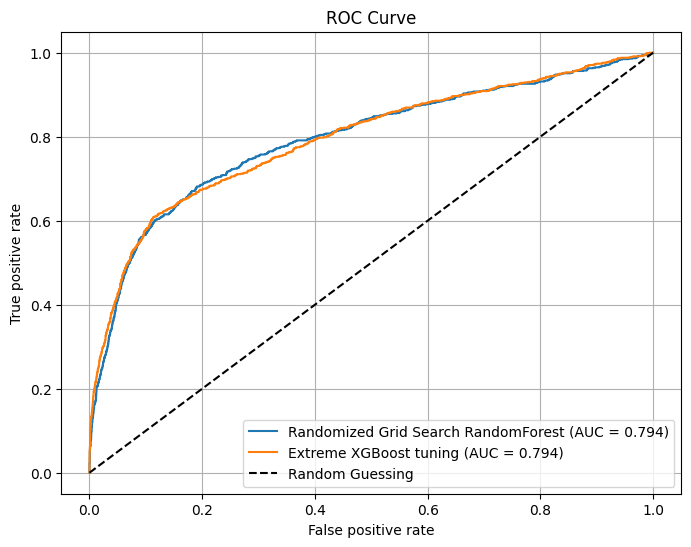

In [42]:
#Need to get the probabilities for the positive class:
y_prob_res_rf = RandomizedSearchCV_rf.predict_proba(test_X)[:, 1]
y_prob_xgb = X_xgb_rand_search.predict_proba(test_X)[:, 1]

fpr_rf, tpr_rf, _ = roc_curve(test_y, y_prob_res_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(test_y, y_prob_xgb)

auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

print('AUC for RandomForest:', auc_rf)
print('AUC for XGBoost:', auc_xgb)

#To plot them:
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Randomized Grid Search RandomForest (AUC = {auc_rf:.3f})')
plt.plot(fpr_xgb, tpr_xgb, label=f'Extreme XGBoost tuning (AUC = {auc_xgb:.3f})')

#RF baseline:
plt.plot([0,1], [0,1], 'k--', label='Random Guessing')
plt.ylabel('True positive rate')
plt.xlabel('False positive rate')
plt.title('ROC Curve')
plt.grid(True)
plt.legend(loc='lower right')

# Precision and recall plot:

### The Precision-Recall plot is more useful here since we have an imbalance dataset. The Two plots below showed the trade-off between precision and recall. The Average-Precision (AP) score explains the ability of the model to identify correctly with the minority class (the client who will subscribe). Comparing to the baseline AP, which is 0.117, the X_XGB AP is 0.49, indicating much higher degrees of predictive power than random guessing. However, our X_XGB model is of moderate performance. Should additional data available to balance out the minority class, the X_XGB model can be further refined.

Average Precision for RGS RandomForest: 0.45948337563247343
Average Precision for XGBoost: 0.48761070659518624
Baseline Average Precision: 0.11673645476462378


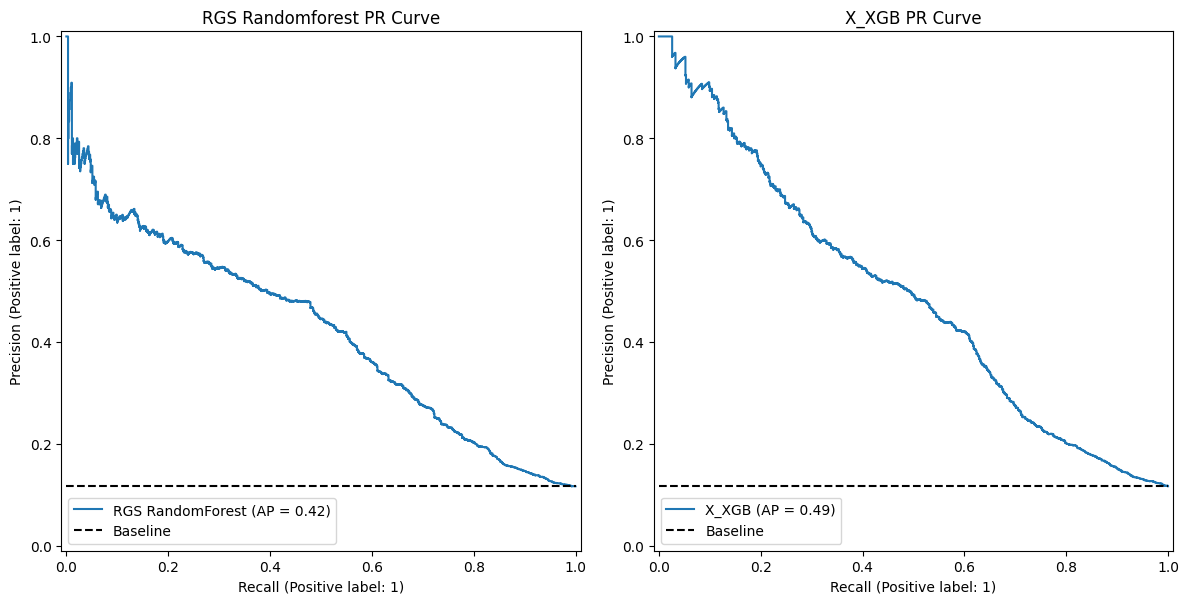

In [44]:
y_prob_rf = RandomizedSearchCV_rf.predict_proba(test_X)[:, 1]
y_prob_xgb = X_xgb_rand_search.predict_proba(test_X)[:, 1]

#Precision, recall curve:
prec_rf, rec_rf, _ = precision_recall_curve(test_y, y_prob_rf)
prec_xgb, rec_xgb, _ = precision_recall_curve(test_y, y_prob_xgb)

#Average precision score:
ap_rf = average_precision_score(test_y, y_prob_rf)
ap_xgb = average_precision_score(test_y, y_prob_xgb)

#Baseline mean (random guessing):
baseline = test_y.mean()

print('Average Precision for RGS RandomForest:', ap_rf)
print('Average Precision for XGBoost:', ap_xgb)
print('Baseline Average Precision:', baseline)

#Plot through sklearn:
fig, axes = plt.subplots(1, 2, figsize=(12, 6)) # Corrected subplots call and added axes
PrecisionRecallDisplay.from_estimator(res_GridSearchCV_rf, test_X, test_y, name='RGS RandomForest', ax=axes[0]) # Added ax=axes[0]
axes[0].set_title('RGS Randomforest PR Curve') # Use axes for setting title
axes[0].hlines(y=baseline, xmin=0, xmax=1, colors="k", linestyles="--", label="Baseline") # Use axes for hlines
axes[0].legend(loc='lower left') # Add legend to the subplot

PrecisionRecallDisplay.from_estimator(X_xgb_rand_search, test_X, test_y, name='X_XGB', ax=axes[1]) # Added ax=axes[1]
axes[1].set_title('X_XGB PR Curve') # Use axes for setting title
axes[1].hlines(y=baseline, xmin=0, xmax=1, colors="k", linestyles="--", label="Baseline") # Use axes for hlines
axes[1].legend(loc='lower left') # Add legend to the subplot

plt.tight_layout() # Adjust layout to prevent overlap
plt.show() # Display the plots